### Black-hole binary formation channels with gaussian mixtures:

1) Load this file (`np.load`) and complete a quick exploration of the data. How many modes do you think you see?

2) Take some time to explore `sklearn.mixture.GaussianMixture`. Check the documentation, some examples, the help menu, etc. You first need to define the model (instance of a class), and then train it on the data using the `fit` method (the data provided are already in the right numpy format!). This will output the trained model, which has various attributes.


3) Complete the fit 10 times with $N=1,...,10$ Gaussians. 

Note: `sklearn` by default will use the so-called [Expectation-Maximization algorithm](https://en.wikipedia.org/wiki/Expectation%E2%80%93maximization_algorithm), which is one of the many great things in data science we don't have time to study in detail.

4) For each of this fits, compute the AIC (easy! It's a attribute of the trained model!). Plot $N$ vs AIC: which model is preferred?

5) Plot the preferred solution on top of the input data. You should get a very nice fit!

6) Understand (i.e. plot) which Gaussian mode corresponds to which part of the input dataset. 

*Hint:* Useful methods here are `score_samples` and `predict_proba`: you'll need them both. Try to understand what they do and how you can put them together.




In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

#### Getting the data:
Let's start by loading the data and visualizing it:

In [2]:
data = np.load('formationchannels.npy')
data[1:]

array([[ 5.94121793],
       [ 6.35914124],
       [ 3.63515689],
       ...,
       [34.34170191],
       [30.27018478],
       [25.93264098]])

Text(0.5, 0, 'BH mass [$M_{\\odot}$]')

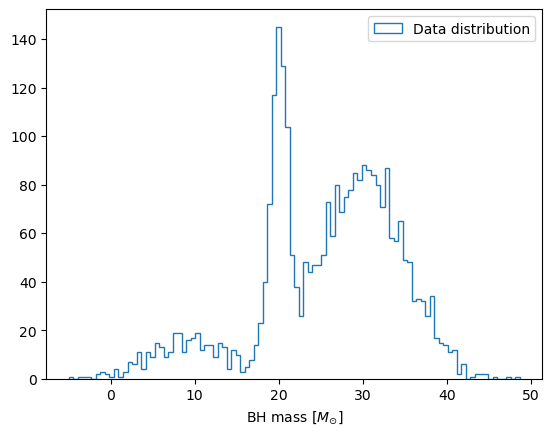

In [3]:
#Let's visualize the data
plt.hist(data, bins = 100, histtype = 'step', label = 'Data distribution')
plt.legend()
plt.xlabel(r'BH mass [$M_{\odot}$]')

It seems like a combination of 3 Gaussians! 

#### Fitting:
But let's try to fit N = 1, ..., 10 gaussians and compute the AIC for all of our models to find the best one!

In [4]:
N = 10
mGauss = [GaussianMixture(n_components = i+1).fit(data) for i in range(N)]
AICs = np.array([mGauss[i].aic(data) for i in range(N)])

The AIC is min for the model with 3 Gaussians.


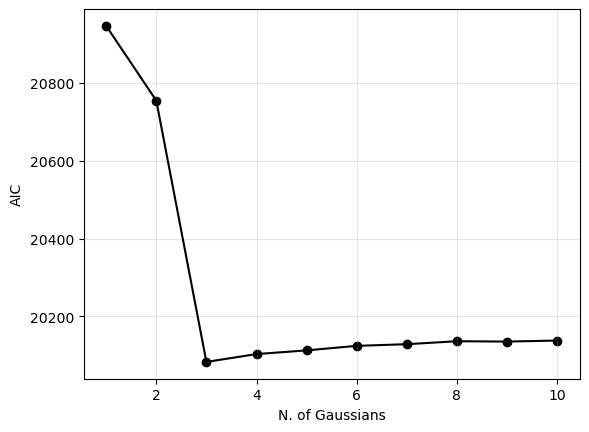

In [6]:
x = np.arange(1, 11, 1)
plt.plot(x, AICs, '-k', label = 'AIC')
plt.scatter(x, AICs, c = 'k')
plt.xlabel('N. of Gaussians')
plt.ylabel('AIC')
plt.grid(alpha = 0.3)

best = x[np.argsort(AICs)[0]]
print(f'The AIC is min for the model with {best} Gaussians.')

Let's now overplot our best model with the data !

In [7]:
best_m = mGauss[2]
samples = np.linspace(-5, 50, 10000)
new_samples = samples[:, np.newaxis]
y = np.exp(best_m.score_samples(X = new_samples))

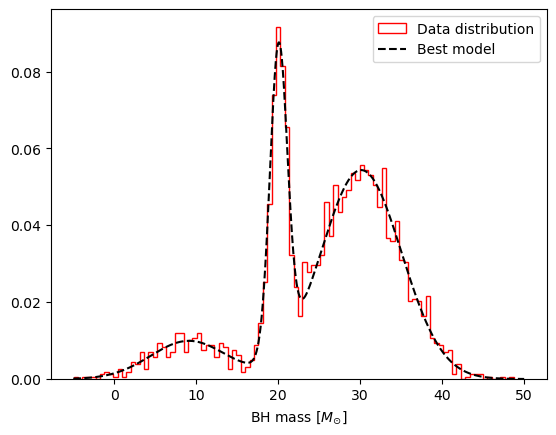

In [8]:
plt.hist(data, bins = 100, histtype = 'step', label = 'Data distribution', density  = True, color = 'r')
plt.plot(samples, y, '--k', label = 'Best model')
plt.xlabel(r'BH mass [$M_{\odot}$]')
plt.legend()

Our model does in fact look very simialr to our data! Great!

#### Further analysis:
Let's now try to understand which Gaussian is responsible for which ponits.

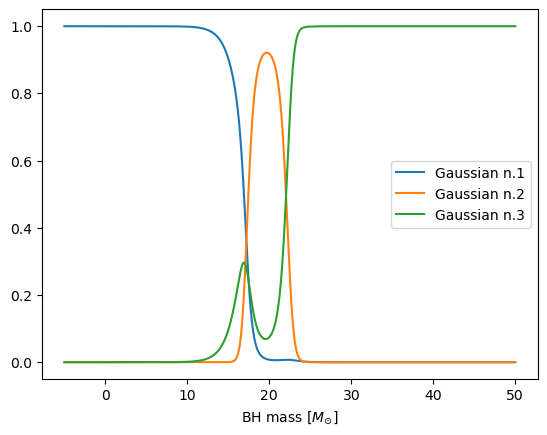

In [9]:
resp = best_m.predict_proba(new_samples)
for i in range(best):
    plt.plot(samples, resp[:,i], label = f'Gaussian n.{i+1}')
plt.xlabel(r'BH mass [$M_{\odot}$]')
plt.legend()

Let's check visullay overplotting the single gaussians to the data!

In [10]:
means = best_m.means_
sigmas = np.array([np.sqrt(np.diag(cov)) for cov in best_m.covariances_])
weights = best_m.weights_
print('The weight of each gaussian component is:', weights)

The weight of each gaussian component is: [0.11625557 0.21408726 0.66965717]


In [11]:
gauss = [stats.norm(m, s) for m, s in zip(means[:, 0], sigmas[:, 0])]

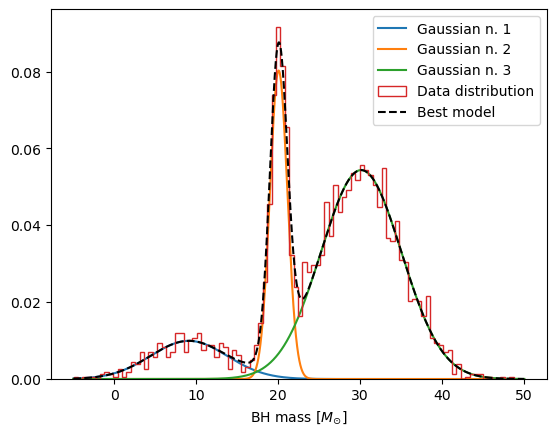

In [12]:
for i in range(3):
    plt.plot(samples, weights[i]*gauss[i].pdf(samples), label = f'Gaussian n. {i+1}')
plt.hist(data, bins = 100, histtype = 'step', linestyle = '-', label = 'Data distribution', density  = True)
plt.plot(samples, y, '--k', label = 'Best model')
plt.xlabel(r'BH mass [$M_{\odot}$]')
plt.legend()

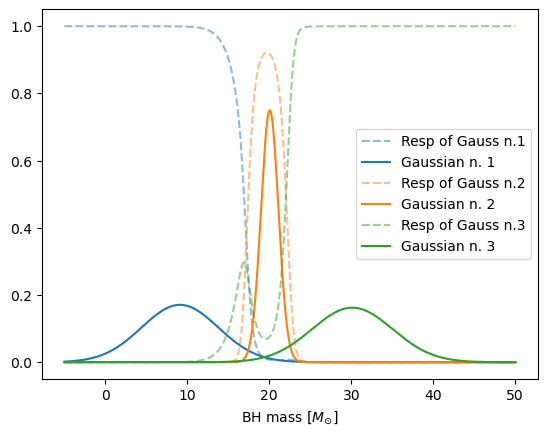

In [13]:
colors = ['C0', 'C1', 'C2']
for i  in range(best):
    plt.plot(samples, resp[:,i], label = f'Resp of Gauss n.{i+1}', linestyle = '--', color = colors[i], alpha = 0.5)
    plt.plot(samples, 2*gauss[i].pdf(samples), label = f'Gaussian n. {i+1}', color = colors[i])
plt.xlabel(r'BH mass [$M_{\odot}$]')
plt.legend()

It looks a bit messy, but it does makes sense!